# Scaling past memory

`fastcellstates`'s search assumes the whole `(genes, cells)` counts matrix
fits in memory: the merge and MCMC/sweep machinery repeatedly revisit
individual cells in essentially random order, which doesn't suit reading
them lazily from disk. So there's no mode that clusters a dataset too big
for RAM directly, and building one would mean rewriting how the kernels
touch data, for an uncertain payoff (random access thrashes against
disk-backed I/O).

There's a cheap way around that instead: fit a `Summary` on a subsample
that *does* fit in memory, then use `Summary.predict_state` (an
independent per-cell argmax against the fitted states; it never needs
another cell's data) to assign every remaining cell, streamed in chunks
straight from disk. This notebook walks through the mechanics with
`io.peek_h5ad` / `io.read_h5ad_subset` / `io.iter_h5ad_chunks`, all backed
by AnnData's own `backed="r"` mode, so no cell you don't touch is ever
loaded.

We use `pbmc3k` purely because it's small, fast, and already familiar from
`getting_started.ipynb`. It does *not* actually need this pattern; it fits
in memory whole. The code below is identical at any scale, and the real
payoff shows up on files too large to load at all (tens of GB), which we
can't conveniently ship or download in a public tutorial.

In [1]:
import numpy as np
import scanpy as sc

import fastcellstates as fcs
from fastcellstates import io

## A stand-in "big" file

`peek_h5ad` / `read_h5ad_subset` / `iter_h5ad_chunks` all take a *path*,
not an in-memory `AnnData`, since the whole point is never fully loading
one. So we write pbmc3k to a real `.h5ad` file first, exactly like a real
large dataset would already exist on disk.

In [2]:
import tempfile
from pathlib import Path

adata = sc.datasets.pbmc3k()
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=200)

path = Path(tempfile.mkdtemp()) / "pbmc3k.h5ad"
adata.write(path)
print(f"{path.name}: {path.stat().st_size / 1e6:.0f} MB")

pbmc3k.h5ad: 20 MB


## Size it up without loading it

`peek_h5ad` reads shape and gene/cell names straight from the file's
metadata, no `X` involved: enough to decide how to subsample.

In [3]:
(n_genes, n_cells), genes, cell_names = io.peek_h5ad(path)
n_genes, n_cells

(13714, 2700)

## Fit on a subsample

Pick a random subsample small enough to comfortably fit in memory (here,
somewhat arbitrarily, 800 of the 2,700 cells: real datasets would use a
much smaller *fraction* but a similarly-sized absolute sample; a few tens
of thousands of cells is already more than enough to resolve real
biological states), and `read_h5ad_subset` pulls out *only* those cells.

In [4]:
rng = np.random.default_rng(0)
sub_idx = np.sort(rng.choice(n_cells, 800, replace=False))
sub_counts, sub_genes, sub_names = io.read_h5ad_subset(path, sub_idx)

summ = fcs.run(sub_counts, fcs.PRESETS["fast"], genes=sub_genes)
print(f"{summ.n_states} states / {summ.n_cells} cells fit on the subsample")

19 states / 800 cells fit on the subsample


## Stream-assign the rest

`Summary.predict_state` scores each query cell independently against the
fitted states, so it can run chunk by chunk. `iter_h5ad_chunks` streams
the file a batch at a time, each batch materialised only when it's
yielded. Each chunk carries the *full* gene panel, so we align it to
`summ.genes` (the subsample's kept genes; a few may have been dropped as
all-zero in that particular 800-cell sample) before scoring.

In [5]:
gene_pos = {g: i for i, g in enumerate(genes)}
keep = np.array([gene_pos[g] for g in summ.genes])

labels = np.empty(n_cells, dtype=np.int64)
offset = 0
n_chunks = 0
for chunk_counts, chunk_genes, chunk_names in io.iter_h5ad_chunks(path, chunk_size=500):
    aligned = chunk_counts[keep, :]
    labels[offset : offset + aligned.shape[1]] = summ.predict_state(aligned)
    offset += aligned.shape[1]
    n_chunks += 1
print(f"assigned {offset} cells across {n_chunks} chunks")

assigned 2700 cells across 6 chunks


## Sanity check: does this match fitting on everything?

pbmc3k comfortably fits in memory, so we can check the streamed
assignment against fitting `fast` on the whole dataset directly. They
won't be identical (a from-scratch fit is a different, larger partition
search than a subsample projection), but they should agree well if the
subsample captured the real structure. Both read the file in the same
(sequential, file-order) order, so the label arrays line up directly.

In [6]:
from sklearn.metrics import adjusted_rand_score

full_counts, full_genes, full_names = io.read(str(path))
summ_full = fcs.run(full_counts, fcs.PRESETS["fast"], genes=full_genes)

ari = adjusted_rand_score(labels, summ_full.labels)
print(f"ARI(subsample + streamed predict_state, full fit) = {ari:.3f}")

ARI(subsample + streamed predict_state, full fit) = 0.573


### Why the ARI isn't higher

0.573 undersells this pattern; pbmc3k is a bad case for it, not a
representative one. The full 2,700-cell fit resolves 26 states, and 13 of
them (half) have fewer than 20 cells; one is a single cell. A DM-optimal
merge only keeps two candidate states apart when there's enough statistical
evidence to justify it, so how many states a fit can resolve scales with
how many cells support each one. The 800-cell subsample (30% of the data)
simply doesn't carry enough copies of these rare states to resolve them
separately, and by chance a few aren't represented at all: that
single-cell state has no representative in the subsample whatsoever.

So a real chunk of the gap isn't the subsample failing to *represent* the
population's structure, it's that the two fits are answering the question
at genuinely different resolutions, and `predict_state` then has no choice
but to fold the cells of an unresolved rare state into whichever coarser
state is nearest. The picture below shows this directly: the subsample
(red) covers the big, dense populations well, but is thin or entirely
absent in some of the small states (blue) that the full fit could resolve
and the subsample fit could not.

At real "too big for memory" scale this matters far less: a subsample of
even a modest *absolute* size (tens of thousands of cells) carries plenty
of copies of any subtype that's more than a rounding error of the
population, which pbmc3k's 2,700 cells and 26-way split doesn't leave much
room for.

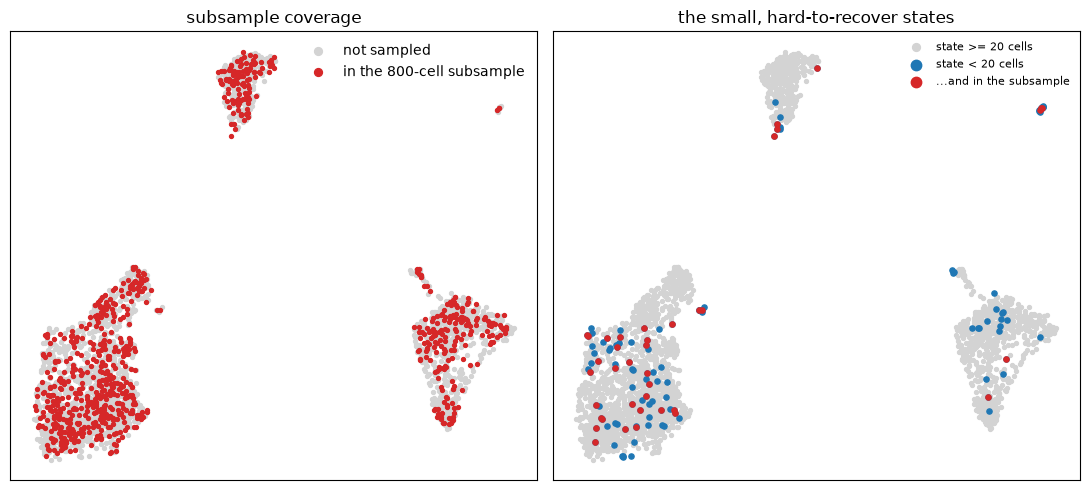

In [7]:
import matplotlib.pyplot as plt

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
xy = adata.obsm["X_umap"]

is_sub = np.zeros(n_cells, dtype=bool)
is_sub[sub_idx] = True
small_state = np.isin(summ_full.labels, np.where(np.bincount(summ_full.labels) < 20)[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(*xy[~is_sub].T, s=8, c="lightgray", label="not sampled")
axes[0].scatter(*xy[is_sub].T, s=8, c="tab:red", label="in the 800-cell subsample")
axes[0].set_title("subsample coverage")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].legend(markerscale=2, frameon=False)

axes[1].scatter(*xy[~small_state].T, s=8, c="lightgray", label="state >= 20 cells")
axes[1].scatter(*xy[small_state].T, s=14, c="tab:blue", label="state < 20 cells")
axes[1].scatter(*xy[is_sub & small_state].T, s=14, c="tab:red", label="...and in the subsample")
axes[1].set_title("the small, hard-to-recover states")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].legend(markerscale=2, frameon=False, fontsize=8)

fig.tight_layout()

See `getting_started.ipynb` for the rest of the workflow (hierarchy,
markers, generative sampling); this notebook is only about the one thing
that changes when the input doesn't fit in memory.

## Where this could go further

A few directions worth naming, not things this notebook actually does:

- **Fit the subsample with `exact`, not `fast`.** The whole reason to
  subsample is to get down to a size anything can run on comfortably; once
  you're there, `fast`'s speed advantage over `exact` stops mattering much
  while its coarser resolution still costs you. On this same 800-cell
  subsample, `exact` runs in under 90 seconds and finds 186 states against
  `fast`'s 19 in 4 seconds, trivial next to the cost of streaming
  through a real multi-GB file. There is little reason to still reach for
  `fast` once subsampling has already paid for the size reduction.

- **Consensus across many subsamples**, to recover states that are
  borderline-resolvable from any one draw: fit many independent
  subsamples, and instead of trusting a single partition, track how often
  pairs of cells that happen to co-occur in a draw end up in the same
  state across draws (consensus/bootstrap clustering, a real and
  established idea). It is not a drop-in extension of what is here,
  though: each draw's own Theta search can converge to a somewhat
  different Theta, so a naive consensus over labels would be quietly
  averaging over slightly different fitted models, not just over sampling
  noise in one fixed model. Reconciling Theta across draws (fixing it
  from a first pass and refitting the rest at that value, say) would
  need solving before this is more than an idea.

- And a genuine limit, not just a gap to engineer around: a state with
  only one or two cells behind it, even when `exact` calls it out as
  distinct, is not something you can say much about scientifically either
  way. There is no internal replication to characterise its own
  distribution or tell a real rare population from one unusual cell, no
  matter how it was found. Below some support threshold, resolving a
  "state" further is not obviously more useful, whichever technique finds
  it.